In [ ]:
import pandas as pd

Exercise 1

In [ ]:

file_path = "train.csv"

titanic_data = pd.read_csv(file_path)

print("Aperçu du dataset :")
print(titanic_data.head())

lignes_avant = titanic_data.shape[0]
print("\nNombre de lignes avant suppression des doublons :", lignes_avant)

doublons = titanic_data.duplicated()

nombre_doublons = doublons.sum()
print("Nombre de lignes en double trouvées :", nombre_doublons)

print("\nLignes en double :")
print(titanic_data[doublons])

titanic_data_sans_doublons = titanic_data.drop_duplicates()

lignes_apres = titanic_data_sans_doublons.shape[0]
print("\nNombre de lignes après suppression des doublons :", lignes_apres)
print("\nRésumé :")
print("Lignes avant :", lignes_avant)
print("Lignes après :", lignes_apres)
print("Nombre de lignes supprimées :", lignes_avant - lignes_apres)

Aperçu du dataset :
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500

Exercise 2

In [ ]:
from sklearn.impute import SimpleImputer

file_path = "train.csv"
df = pd.read_csv(file_path)

print("Valeurs manquantes avant traitement :")
print(df.isnull().sum())

df_clean = df.copy()

age_imputer = SimpleImputer(strategy="median")
df_clean["Age"] = age_imputer.fit_transform(df_clean[["Age"]])

embarked_imputer = SimpleImputer(strategy="most_frequent")
df_clean["Embarked"] = embarked_imputer.fit_transform(df_clean[["Embarked"]]).ravel()

cabin_imputer = SimpleImputer(strategy="constant", fill_value="Unknown")
df_clean["Cabin"] = cabin_imputer.fit_transform(df_clean[["Cabin"]]).ravel()

print("\nValeurs manquantes après traitement :")
print(df_clean.isnull().sum())

print("\nAperçu du dataset nettoyé :")
print(df_clean.head())

Valeurs manquantes avant traitement :
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Valeurs manquantes après traitement :
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Aperçu du dataset nettoyé :
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.

Exercise 3

In [ ]:
from sklearn.preprocessing import LabelEncoder

file_path = "train.csv"

df = pd.read_csv(file_path)

print("Aperçu du dataset :")
print(df.head())

Aperçu du dataset :
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500

Exercise 4

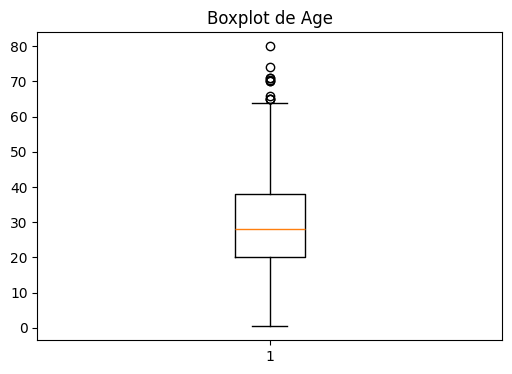

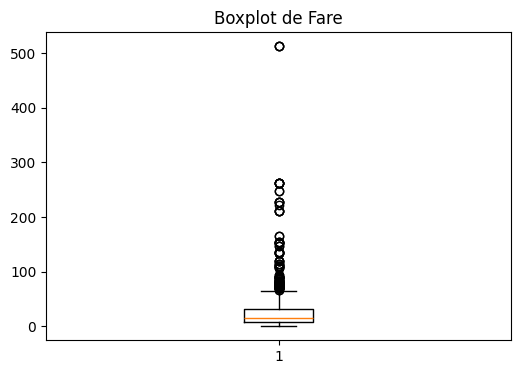

Nombre de valeurs aberrantes Age : 11
Nombre de valeurs aberrantes Fare : 116

Avant traitement :
              Age        Fare
count  714.000000  891.000000
mean    29.699118   32.204208
std     14.526497   49.693429
min      0.420000    0.000000
25%     20.125000    7.910400
50%     28.000000   14.454200
75%     38.000000   31.000000
max     80.000000  512.329200

Après plafonnement quantile 0.98 :
              Age        Fare
count  714.000000  891.000000
mean    29.586513   30.678483
std     14.230056   39.904946
min      0.420000    0.000000
25%     20.125000    7.910400
50%     28.000000   14.454200
75%     38.000000   31.000000
max     62.740000  211.337500

Après transformation logarithmique de Fare :
             Fare    Fare_log
count  891.000000  891.000000
mean    32.204208    2.962246
std     49.693429    0.969048
min      0.000000    0.000000
25%      7.910400    2.187218
50%     14.454200    2.737881
75%     31.000000    3.465736
max    512.329200    6.240917

Suppressi

In [8]:
import numpy as np
import matplotlib.pyplot as plt

file_path = "train.csv"

df = pd.read_csv(file_path)

plt.figure(figsize=(6, 4))
plt.boxplot(df["Age"].dropna())
plt.title("Boxplot de Age")
plt.show()

plt.figure(figsize=(6, 4))
plt.boxplot(df["Fare"].dropna())
plt.title("Boxplot de Fare")
plt.show()

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_limit) | (data[column] > upper_limit)]

    return outliers, lower_limit, upper_limit

age_outliers, age_lower, age_upper = detect_outliers_iqr(df, "Age")
fare_outliers, fare_lower, fare_upper = detect_outliers_iqr(df, "Fare")

print("Nombre de valeurs aberrantes Age :", age_outliers.shape[0])
print("Nombre de valeurs aberrantes Fare :", fare_outliers.shape[0])

df_cap = df.copy()

age_q98 = df_cap["Age"].quantile(0.98)
fare_q98 = df_cap["Fare"].quantile(0.98)

df_cap["Age"] = np.where(df_cap["Age"] > age_q98, age_q98, df_cap["Age"])
df_cap["Fare"] = np.where(df_cap["Fare"] > fare_q98, fare_q98, df_cap["Fare"])

df_log = df.copy()
df_log["Fare_log"] = np.log1p(df_log["Fare"])

df_remove = df[df["Fare"] <= fare_upper]

print("\nAvant traitement :")
print(df[["Age", "Fare"]].describe())

print("\nAprès plafonnement quantile 0.98 :")
print(df_cap[["Age", "Fare"]].describe())

print("\nAprès transformation logarithmique de Fare :")
print(df_log[["Fare", "Fare_log"]].describe())

print("\nSuppression des outliers Fare :")
print("Lignes avant :", df.shape[0])
print("Lignes après :", df_remove.shape[0])
print("Lignes supprimées :", df.shape[0] - df_remove.shape[0])

Exercise 5

In [13]:
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler

file_path = "train.csv"

df = pd.read_csv(file_path)

df_clean = df.copy()

df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])
df_clean["Cabin"] = df_clean["Cabin"].fillna("Unknown")

df_scaled = df_clean.copy()

age_q98 = df_scaled["Age"].quantile(0.98)
fare_q98 = df_scaled["Fare"].quantile(0.98)

df_scaled["Age"] = np.where(df_scaled["Age"] > age_q98, age_q98, df_scaled["Age"])
df_scaled["Fare"] = np.where(df_scaled["Fare"] > fare_q98, fare_q98, df_scaled["Fare"])

standard_scaler = StandardScaler()
df_scaled["Age_standardized"] = standard_scaler.fit_transform(df_scaled[["Age"]])

minmax_scaler = MinMaxScaler()
df_scaled["Fare_normalized"] = minmax_scaler.fit_transform(df_scaled[["Fare"]])

print("Aperçu des colonnes mises à l'échelle :")
print(df_scaled[[
    "Age",
    "Age_standardized",
    "Fare",
    "Fare_normalized"
]].head())

print("\nStatistiques après mise à l'échelle :")
print(df_scaled[[
    "Age_standardized",
    "Fare_normalized"
]].describe())

Aperçu des colonnes mises à l'échelle :
    Age  Age_standardized     Fare  Fare_normalized
0  22.0         -0.570988   7.2500         0.034305
1  38.0          0.687580  71.2833         0.337296
2  26.0         -0.256346   7.9250         0.037499
3  35.0          0.451599  53.1000         0.251257
4  35.0          0.451599   8.0500         0.038091

Statistiques après mise à l'échelle :
       Age_standardized  Fare_normalized
count      8.910000e+02       891.000000
mean       1.674680e-16         0.145163
std        1.000562e+00         0.188821
min       -2.268481e+00         0.000000
25%       -5.709877e-01         0.037430
50%       -9.902481e-02         0.068394
75%        4.515986e-01         0.146685
max        2.575432e+00         1.000000


Exercise 6

In [11]:
from sklearn.preprocessing import LabelEncoder

# Charger le dataset
file_path = "train.csv"

df = pd.read_csv(file_path)

# Copie du dataset
df_encoded = df.copy()

# 1. Gestion des valeurs manquantes
df_encoded["Age"] = df_encoded["Age"].fillna(df_encoded["Age"].median())
df_encoded["Embarked"] = df_encoded["Embarked"].fillna(df_encoded["Embarked"].mode()[0])
df_encoded["Cabin"] = df_encoded["Cabin"].fillna("Unknown")

# 2. Création de la colonne Title
df_encoded["Title"] = df_encoded["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)

rare_titles = [
    "Lady", "Countess", "Capt", "Col", "Don", "Dr",
    "Major", "Rev", "Sir", "Jonkheer", "Dona"
]

df_encoded["Title"] = df_encoded["Title"].replace(rare_titles, "Rare")

df_encoded["Title"] = df_encoded["Title"].replace({
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
})

# 3. Identifier les colonnes catégorielles
categorical_columns = df_encoded.select_dtypes(include=["object"]).columns

print("Colonnes catégorielles avant encodage :")
print(categorical_columns)

# 4. Encodage par étiquette
label_encoder = LabelEncoder()

df_encoded["Sex_label"] = label_encoder.fit_transform(df_encoded["Sex"])
df_encoded["Embarked_label"] = label_encoder.fit_transform(df_encoded["Embarked"])
df_encoded["Title_label"] = label_encoder.fit_transform(df_encoded["Title"])

print("\nEncodage par étiquette :")
print(df_encoded[[
    "Sex", "Sex_label",
    "Embarked", "Embarked_label",
    "Title", "Title_label"
]].head())

# 5. Encodage one-hot
df_final = pd.get_dummies(
    df_encoded,
    columns=["Sex", "Embarked", "Title"],
    drop_first=True
)

print("\nDataset après encodage one-hot :")
print(df_final.head())

print("\nColonnes après encodage :")
print(df_final.columns)

Colonnes catégorielles avant encodage :
Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked', 'Title'], dtype='object')

Encodage par étiquette :
      Sex  Sex_label Embarked  Embarked_label Title  Title_label
0    male          1        S               2    Mr            2
1  female          0        C               0   Mrs            3
2  female          0        S               2  Miss            1
3  female          0        S               2   Mrs            3
4    male          1        S               2    Mr            2

Dataset après encodage one-hot :
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0    

Exercise 7

In [1]:

file_path = "train.csv"

df = pd.read_csv(file_path)

df["Age"] = df["Age"].fillna(df["Age"].median())

bins = [0, 12, 18, 60, 100]
labels = ["Enfant", "Adolescent", "Adulte", "Senior"]

df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

age_group_encoded = pd.get_dummies(df["AgeGroup"], prefix="AgeGroup")

df = pd.concat([df, age_group_encoded], axis=1)

print(df[[
    "Age",
    "AgeGroup",
    "AgeGroup_Enfant",
    "AgeGroup_Adolescent",
    "AgeGroup_Adulte",
    "AgeGroup_Senior"
]].head(10))

    Age    AgeGroup  AgeGroup_Enfant  AgeGroup_Adolescent  AgeGroup_Adulte  \
0  22.0      Adulte            False                False             True   
1  38.0      Adulte            False                False             True   
2  26.0      Adulte            False                False             True   
3  35.0      Adulte            False                False             True   
4  35.0      Adulte            False                False             True   
5  28.0      Adulte            False                False             True   
6  54.0      Adulte            False                False             True   
7   2.0      Enfant             True                False            False   
8  27.0      Adulte            False                False             True   
9  14.0  Adolescent            False                 True            False   

   AgeGroup_Senior  
0            False  
1            False  
2            False  
3            False  
4            False  
5            Fa